<a href="https://colab.research.google.com/github/ibrahimkh-cmd/ISAC_R-seauV-hiculaire/blob/main/TP1_enonce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 — Réseaux de véhicules : modélisation par graphes et diffusion d'information  

### Module ISAC — réseaux véhiculaires coopératifs

**Comment travailler ce TP**
- Exécuter les cellules **dans l'ordre**.
- Compléter les zones `TODO`.
- Les blocs **Question** attendent une réponse écrite et argumentée.
- Le TP se déroule en deux parties, **A puis B**, qui s'enchaînent : les fonctions construites en Partie A sont directement réutilisées en Partie B.

# Partie A — Modéliser le réseau : prise en main des graphes

Avant d'étudier *comment* l'information circule, on apprend à représenter un réseau de véhicules par un **graphe** et à mesurer sa structure. On termine par un réseau **qui bouge**, modélisé comme une suite de graphes — le support de toute la suite du TP.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython import display

tailleMap = 200   # taille du côté de la carte (la zone est tailleMap x tailleMap)

## 1. Un graphe de proximité

On place `N` véhicules sur une carte carrée de côté `tailleMap`. Deux véhicules peuvent
communiquer (il y a une **arête** entre eux) si et seulement s'ils sont à portée radio,
c'est-à-dire à une distance inférieure ou égale à `R`.

In [2]:
def graphe_proximite(positions, R):
    """Construit le graphe de proximité d'un ensemble de véhicules.

    Paramètres :
        positions : tableau numpy de forme (N, 2). Chaque ligne i contient
                    les coordonnées (x, y) du véhicule i sur la carte.
        R         : portée radio (en mètres). Deux véhicules sont reliés
                    par une arête si leur distance est inférieure ou égale à R.
    Retourne :
        G : graphe networkx dont les nœuds sont les véhicules (0..N-1),
            chacun portant son attribut 'pos' (sa position).
    """
    G = nx.Graph()
    N = len(positions)
    for i in range(N):
        G.add_node(i, pos=positions[i])
    for i in range(N):
        for j in range(i + 1, N):
            # --- À COMPLÉTER CI-DESSOUS  TODO---
            distance = np.linalg.norm(positions[i] - positions[j])
            # if ...:
            #     G.add_edge(.,.)

    return G

rng = np.random.default_rng()            # tirages aléatoires : les résultats varient à chaque exécution
N = 15                                   # Nombre de voitures
positions = rng.random((N, 2)) * tailleMap
R = 50.0                                  # portée radio (essayer aussi 50, puis 100)
G = graphe_proximite(positions, R)
print("Nombre d'arêtes :", G.number_of_edges())

Nombre d'arêtes : 25


### Visualiser le réseau

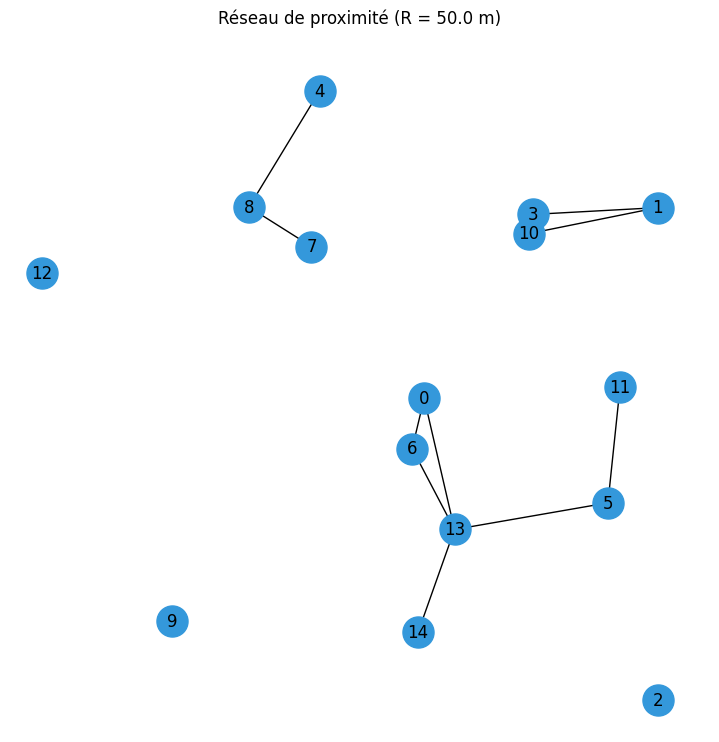

In [ ]:
pos_dict = {i: positions[i] for i in range(N)}
plt.figure(figsize=(7, 7))
nx.draw(G, pos=pos_dict, with_labels=True, node_color='#3498db', node_size=500)
plt.title(f"Réseau de proximité (R = {R} m)")
plt.show()

## 2. Mesurer la structure

Trois indicateurs simples décrivent déjà beaucoup le réseau :
- le **degré** d'un véhicule : son nombre de voisins ;
- le nombre de **composantes connexes** : le nombre d'îlots de véhicules qui ne peuvent pas se joindre ;
- le **diamètre** : le plus long des plus courts chemins (en nombre de sauts) dans le plus gros îlot.

In [ ]:
degres = dict(G.degree())
print("Degré moyen :", round(np.mean(list(degres.values())), 2))

composantes = list(nx.connected_components(G))
print("Nombre de composantes connexes :", len(composantes))

plus_grosse = max(composantes, key=len)
sousG = G.subgraph(plus_grosse)
if len(plus_grosse) > 1:
    print("Diamètre de la plus grosse composante :", nx.diameter(sousG), "sauts")
else:
    print("La plus grosse composante est un seul nœud (réseau très fragmenté).")

Degré moyen : 1.47
Nombre de composantes connexes : 6
Diamètre de la plus grosse composante : 3 sauts


## 3. Question critique — l'effet de la portée R

On fait varier `R` et on regarde la taille de la plus grosse composante connexe
(en % du réseau). Exécuter la cellule, puis répondre en dessous.

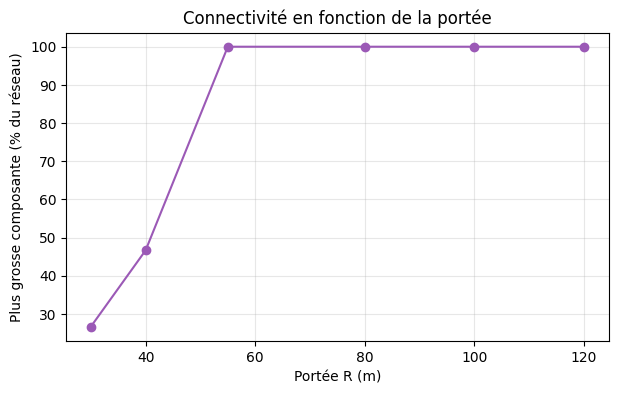

In [3]:
valeurs_R = [30, 40, 55, 80, 100, 120]
taille_max = []
for r in valeurs_R:
    g = graphe_proximite(positions, r)
    plus_grosse = max(nx.connected_components(g), key=len)
    taille_max.append(len(plus_grosse) / N * 100)

plt.figure(figsize=(7, 4))
plt.plot(valeurs_R, taille_max, 'o-', color='#9b59b6')
plt.xlabel("Portée R (m)"); plt.ylabel("Plus grosse composante (% du réseau)")
plt.title("Connectivité en fonction de la portée"); plt.grid(alpha=0.3)
plt.show()

**Question : Décrire ce qui est observé, et expliquer pourquoi une portée trop faible empêchera toute diffusion, quel que soit le protocole utilisé.**

**Réponse :**

## 4. Un réseau qui bouge : le graphe dynamique

Les véhicules se déplacent. On ne décrit donc pas un seul graphe, mais une **suite de graphes**
(un par instant), appelés *snapshots*. À chaque pas de temps, on recalcule les arêtes selon
les nouvelles positions (les véhicules rebondissent sur les bords de la carte).

In [4]:
def generer_snapshots(N, R, steps, vmax, tailleMap):
    """Génère la suite des graphes (snapshots) d'un réseau de véhicules mobiles.

    Paramètres :
        N         : nombre de véhicules.
        R         : portée radio (mètres) utilisée pour construire chaque graphe.
        steps     : nombre de pas de temps simulés (un graphe par pas).
        vmax      : vitesse maximale des véhicules (amplitude du déplacement par pas).
        tailleMap : taille du côté de la carte carrée (la zone est tailleMap x tailleMap).
    Retourne :
        snaps : liste de `steps` graphes networkx, un par instant.
    Remarque : les positions et vitesses initiales sont tirées au hasard à chaque
    exécution (pas de graine fixe), les résultats varient donc d'un lancement à l'autre.
    """
    rng = np.random.default_rng()
    pos = rng.random((N, 2)) * tailleMap
    vel = (rng.random((N, 2)) - 0.5) * vmax
    snaps = []
    for _ in range(steps):
        pos += vel
        hors = (pos < 0) | (pos > tailleMap)   # rebond sur les bords
        vel[hors] *= -1
        pos = np.clip(pos, 0, tailleMap)
        snaps.append(graphe_proximite(pos.copy(), R))
    return snaps

snapshots = generer_snapshots(N=15, R=40, steps=60, vmax=8, tailleMap=tailleMap)
print("Nombre de snapshots :", len(snapshots))

Nombre de snapshots : 60


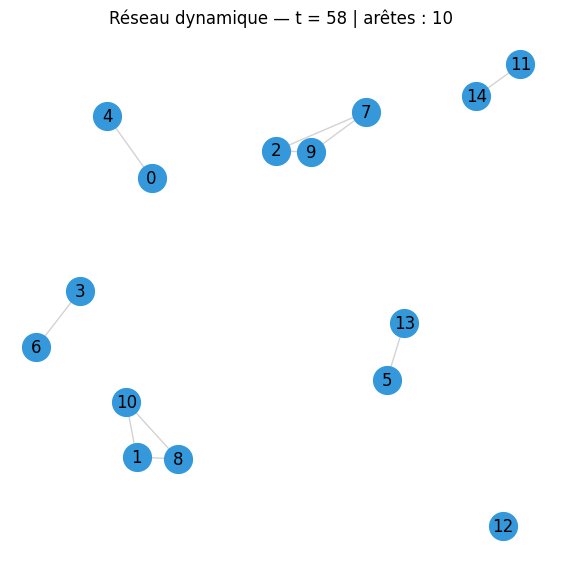

In [10]:
# Animation de la mobilité
fig, ax = plt.subplots(figsize=(7, 7))
for t in range(0, len(snapshots), 2):
    ax.clear()
    G = snapshots[t]
    pos_dict = nx.get_node_attributes(G, 'pos')
    nx.draw(G, pos=pos_dict, with_labels=True, node_color='#3498db',
            node_size=400, edge_color='lightgray', ax=ax)
    ax.set_xlim(-10, tailleMap + 10); ax.set_ylim(-10, tailleMap + 10)
    ax.set_title(f"Réseau dynamique — t = {t} | arêtes : {G.number_of_edges()}")
    display.display(fig); display.clear_output(wait=True)
    time.sleep(0.1) # Modifiez ce paramètre pour mieux visulaiser le changement de graphe.
display.display(fig); plt.close(fig)

### Question critique

L'animation montre que le nombre d'arêtes change au cours du temps : des liens
apparaissent et disparaissent.
*Pourquoi est-ce un problème pour diffuser une information ? Qu'est-ce qui change par rapport à un réseau fixe ?*


**Réponse :**

## 5. Ajouter une infrastructure : le nœud RSU (hub)

Jusqu'ici le réseau n'est fait que de véhicules. En pratique, on installe au bord des routes des **RSU** (*Road-Side Units*) : des nœuds **fixes**, à **grande portée** et gros budget, qui servent de **relais d'infrastructure** (un nœud « edge »). Du point de vue du graphe, une RSU est un **hub** : un sommet relié à de nombreux véhicules à la fois. Son intérêt se voit quand le réseau est **fragmenté** en groupes isolés — la RSU les **relie**.

Sans RSU : composantes connexes = 1
Avec RSU : composantes connexes = 1


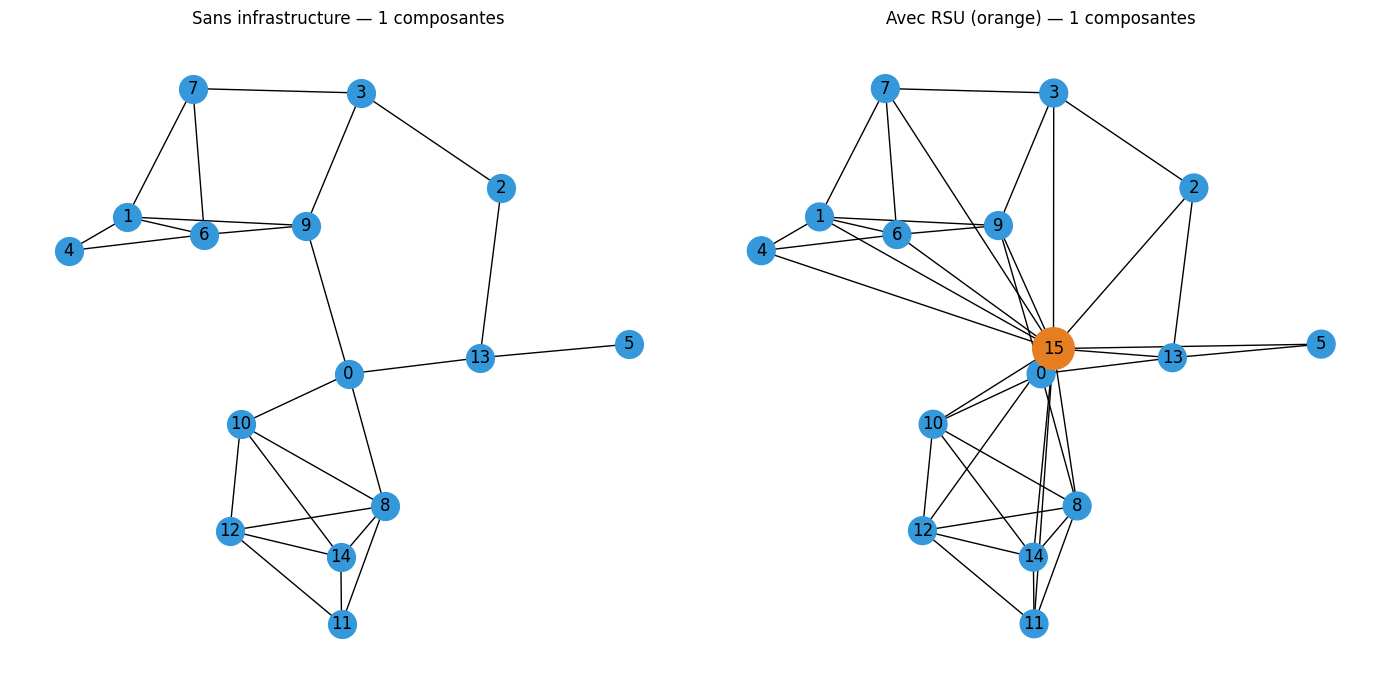

In [13]:
R_RSU = 140.0                                  # portée (large) de la RSU
rsu_pos = np.array([tailleMap / 2, tailleMap / 2])   # une RSU posée au centre

def graphe_avec_rsu(positions, R, rsu_pos, R_RSU):
    """Graphe des véhicules + un nœud RSU fixe relié aux véhicules dans son rayon R_RSU."""
    G = graphe_proximite(positions, R)
    rsu = len(positions)                       # indice du nœud RSU
    G.add_node(rsu, pos=rsu_pos)
    for i in range(len(positions)):
        if np.linalg.norm(positions[i] - rsu_pos) <= R_RSU:
            G.add_edge(i, rsu)
    return G, rsu

G_sans = graphe_proximite(positions, )
G_avec, rsu = graphe_avec_rsu(positions, R, rsu_pos, R_RSU)
print('Sans RSU : composantes connexes =', nx.number_connected_components(G_sans))
print('Avec RSU : composantes connexes =', nx.number_connected_components(G_avec))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
pos_dict = {i: positions[i] for i in range(N)}
nx.draw(G_sans, pos=pos_dict, with_labels=True, node_color='#3498db', node_size=400, ax=axes[0])
axes[0].set_title(f'Sans infrastructure — {nx.number_connected_components(G_sans)} composantes')
pos_dict2 = dict(pos_dict); pos_dict2[rsu] = rsu_pos
couleurs = ['#e67e22' if n == rsu else '#3498db' for n in G_avec.nodes()]
tailles  = [900 if n == rsu else 400 for n in G_avec.nodes()]
nx.draw(G_avec, pos=pos_dict2, with_labels=True, node_color=couleurs, node_size=tailles, ax=axes[1])
axes[1].set_title(f'Avec RSU (orange) — {nx.number_connected_components(G_avec)} composantes')
plt.tight_layout(); plt.show()


### Question critique

Pourquoi une RSU fait-elle surtout chuter le **nombre de composantes connexes** quand le réseau est fragmenté (faible portée `R`), et beaucoup moins quand le réseau est déjà bien connecté ?

**Réponse :**

# Partie B — Faire circuler une information : flooding vs gossip

*Transition.* Nous savons maintenant représenter un réseau dynamique. Mais un réseau n'a d'intérêt que s'il fait **circuler** de l'information. Un véhicule (la *source*) détient une information : comment la propager à tout le réseau construit en Partie A ? On compare deux stratégies opposées — le **flooding** et le **gossip** — et on mesure le compromis **couverture / coût**.

On réutilise directement les outils de la Partie A (`graphe_proximite`, `generer_snapshots`) ; il suffit de construire le réseau de travail.

In [14]:
# --- On reprend l'outillage de la Partie A (déjà défini ci-dessus) ---
# Pour bien observer la diffusion, on construit un réseau un peu plus grand.
tailleMap = 300                 # zone un peu plus large que pour la prise en main
N, steps = 20, 22
snapshots = generer_snapshots(N=N, R=80, steps=steps, vmax=8, tailleMap=tailleMap)
source = 0                      # le véhicule qui détient l'information au départ
print("Réseau de diffusion :", N, "véhicules,", steps, "pas de temps")

Réseau de diffusion : 20 véhicules, 22 pas de temps


## 1. Le flooding : émettre à tous les voisins

À chaque pas de temps, **tout** véhicule informé transmet l'information à **tous** ses voisins.
C'est rapide et fiable, mais cela génère beaucoup de transmissions. On compte une transmission
(`tx`) à chaque fois qu'un véhicule informé parle à un voisin.

In [15]:
def flooding(snapshots, source=0):
    """Simule la diffusion par flooding sur une suite de snapshots.

    Paramètres :
        snapshots : liste de graphes networkx (un par pas de temps).
        source    : identifiant du véhicule qui connaît l'information au départ.
    Retourne :
        history  : liste, pour chaque pas, de l'ensemble des véhicules informés.
        tx_count : liste du nombre de transmissions effectuées à chaque pas.
    """
    informed = {source}
    history = [informed.copy()]
    tx_count = [0]
    for G in snapshots[1:]:
        tx = 0
        nouveaux = set()
        for node in informed:
            #TODO
            #   Pour chaque 'voisin' de 'node' dans G.neighbors(node) :
                  #     1. Si le voisin n'est pas encore informé : l'ajouter à 'nouveaux'
                  #     2. Incrémenter le compteur de transmissions 'tx' de 1

        informed |= nouveaux
        history.append(informed.copy())
        tx_count.append(tx)
    return history, tx_count

## 2. Le gossip : émettre à un seul voisin choisi au hasard

À chaque pas, un véhicule informé ne contacte **qu'un seul voisin tiré au hasard**
(on pourra utiliser `np.random.choice`). Beaucoup moins de transmissions, mais la
diffusion est plus lente et son déroulement dépend du hasard.

In [16]:
def gossip(snapshots, source=0):
    """Simule la diffusion par gossip sur une suite de snapshots.

    Paramètres :
        snapshots : liste de graphes networkx (un par pas de temps).
        source    : identifiant du véhicule qui connaît l'information au départ.
    Retourne :
        history  : liste, pour chaque pas, de l'ensemble des véhicules informés.
        tx_count : liste du nombre de transmissions effectuées à chaque pas.
    """
    informed = {source}
    history = [informed.copy()]
    tx_count = [0]
    for G in snapshots[1:]:
        tx = 0
        nouveaux = set()
        for node in informed:
            voisins = list(G.neighbors(node))
            #TODO
            #   S'il a au moins un voisin :
                   #     1. Choisir une cible au hasard de voisin ( np.random.choice )
                   #     2. Si la cible n'est pas encore informé, l'ajouter à 'nouveaux'
                   #     3. Incrémenter 'tx' de 1
        informed |= nouveaux
        history.append(informed.copy())
        tx_count.append(tx)
    return history, tx_count

## 3. Lancer les deux et mesurer

La **couverture** mesure la proportion du réseau informée à un instant donné :

$$\text{Couverture (\%)} = \frac{\text{Nombre de véhicules informés}}{\text{Nombre total de véhicules}} \times 100$$

In [17]:
hist_flood, tx_flood = flooding(snapshots, source)
hist_gossip, tx_gossip = gossip(snapshots, source)

def courbe_couverture(history):
    """Convertit un historique de diffusion en courbe de couverture.

    Paramètres :
        history : liste, pour chaque pas de temps, de l'ensemble des véhicules informés.
    Retourne :
        valeurs : liste de la couverture (%) à chaque pas de temps.
    """
    valeurs = []
    for infos in history:
        #TODO
        #couverture = ...
        valeurs.append(couverture)
    return valeurs

cov_flood = courbe_couverture(hist_flood)
cov_gossip = courbe_couverture(hist_gossip)
print("Couverture finale — flooding :", round(cov_flood[-1]), "%  |  gossip :", round(cov_gossip[-1]), "%")

Couverture finale — flooding : 80 %  |  gossip : 55 %


### Visualiser la propagation (rouge = source, orange = informé, bleu = ignorant)

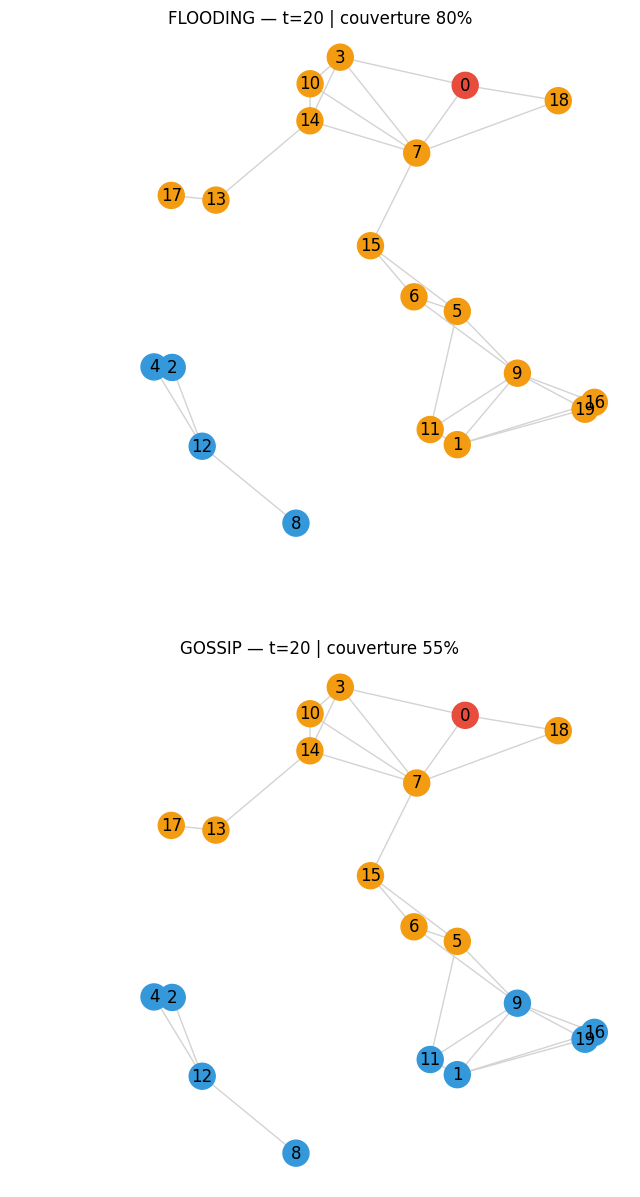

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(8, 15))
for t in range(0, steps, 2):
    G = snapshots[t]; pos_dict = nx.get_node_attributes(G, 'pos')
    for ax, hist, nom in [(axes[0], hist_flood, "FLOODING"), (axes[1], hist_gossip, "GOSSIP")]:
        ax.clear()
        couleurs = []
        for node in G.nodes():
            if node == source: couleurs.append('#e74c3c')
            elif node in hist[t]: couleurs.append('#f39c12')
            else: couleurs.append('#3498db')
        nx.draw(G, pos=pos_dict, with_labels=True, node_color=couleurs,
                node_size=350, edge_color='lightgray', ax=ax)
        cov = len(hist[t]) / N * 100
        ax.set_title(f"{nom} — t={t} | couverture {cov:.0f}%")
        ax.set_xlim(-10, tailleMap + 10); ax.set_ylim(-10, tailleMap + 10)
    display.display(fig); display.clear_output(wait=True)
    time.sleep(0.1)
display.display(fig); plt.close(fig)

### Le compromis : couverture vs coût

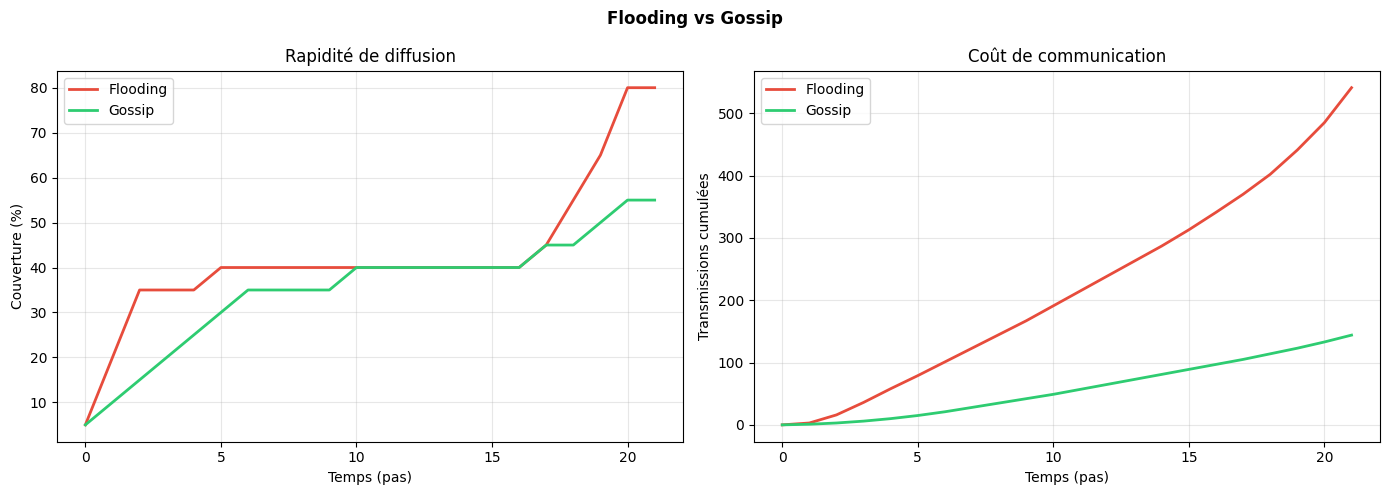

Coût total — flooding : 541 transmissions  |  gossip : 144


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cov_flood, label='Flooding', color='#e74c3c', linewidth=2)
axes[0].plot(cov_gossip, label='Gossip', color='#2ecc71', linewidth=2)
axes[0].set_xlabel('Temps (pas)'); axes[0].set_ylabel('Couverture (%)')
axes[0].set_title('Rapidité de diffusion'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(np.cumsum(tx_flood), label='Flooding', color='#e74c3c', linewidth=2)
axes[1].plot(np.cumsum(tx_gossip), label='Gossip', color='#2ecc71', linewidth=2)
axes[1].set_xlabel('Temps (pas)'); axes[1].set_ylabel('Transmissions cumulées')
axes[1].set_title('Coût de communication'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Flooding vs Gossip', fontweight='bold'); plt.tight_layout(); plt.show()

print(f"Coût total — flooding : {sum(tx_flood)} transmissions  |  gossip : {sum(tx_gossip)}")

## 4. Questions critiques

**Q1.** Pourquoi le gossip est-il plus lent que le flooding, mais beaucoup moins coûteux ?

**Réponse :**

**Q2.** Dans un réseau véhiculaire réel où la bande passante est limitée, lequel choisir ? Le choix dépend-il de l'urgence de l'information ? Proposer un protocole de diffusion pour optimiser la transmission des informations ?

**Réponse :**

## 5. CAM : et si chaque véhicule diffusait sa position en permanence ?

Dans les réseaux véhiculaires réels (standards **ETSI ITS-G5 / V2X**), chaque véhicule émet périodiquement un **CAM** (*Cooperative Awareness Message*) : un petit message qui annonce sa **propre position** à ses voisins. C'est ce qui crée la **conscience** de qui se trouve autour. Mais si **tout le monde** émet à **chaque pas**, combien de transmissions cela représente-t-il ? Mesurons ce coût (l'airtime) sur le réseau dynamique.

Airtime total des CAM sur 55 pas : 4666 transmissions
Moyenne par pas : 85 transmissions


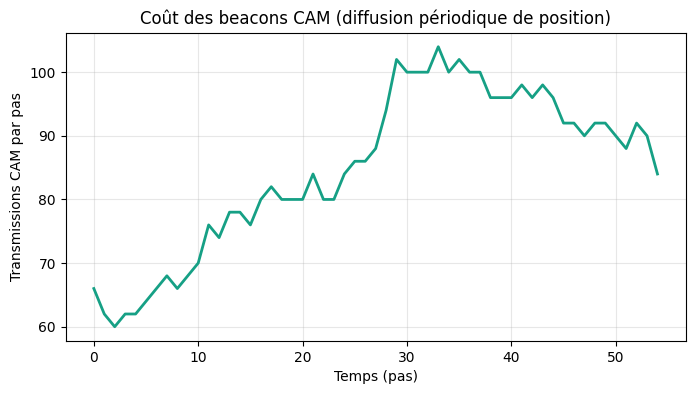

In [ ]:
def cout_cam(snapshots):
    """Airtime des CAM : chaque véhicule diffuse sa position à tous ses voisins, à chaque pas."""
    par_pas = []
    for G in snapshots:
        tx = sum(G.degree(n) for n in G.nodes())   # chaque nœud émet vers chacun de ses voisins
        par_pas.append(tx)
    return par_pas


snapshots = generer_snapshots(N=22, R=80, steps=55, vmax=8, tailleMap=tailleMap) #changer la valeur de N et conclure sur le coût d'émission
cam_par_pas = cout_cam(snapshots)


print('Airtime total des CAM sur', len(snapshots), 'pas :', sum(cam_par_pas), 'transmissions')
print('Moyenne par pas :', round(np.mean(cam_par_pas)), 'transmissions')

plt.figure(figsize=(8, 4))
plt.plot(cam_par_pas, color='#16a085', linewidth=2)
plt.xlabel('Temps (pas)'); plt.ylabel('Transmissions CAM par pas')
plt.title('Coût des beacons CAM (diffusion périodique de position)')
plt.grid(alpha=0.3); plt.show()

**Ce que cela montre.** Le coût des CAM **croît avec la densité** du réseau (plus de voisins = plus de transmissions). D'où les deux idées développées dans le **TP2** : (1) **borner** la diffusion à une **zone de pertinence** géographique (*geocast*), et (2) **prioriser** les informations par leur **valeur** (VoI) plutôt que de tout émettre au hasard.

---
## Conclusion du TP1

**Partie A — modéliser**
- Un réseau de véhicules se modélise par un **graphe de proximité** (arête si distance ≤ portée).
- La **portée** conditionne la connectivité : trop faible, le réseau est fragmenté.
- Un réseau qui bouge est une **suite de graphes** ; les liens sont **intermittents**.

**Partie B — diffuser**
- **Flooding** : rapide, fiable, coûteux (beaucoup de redondance).
- **Gossip** : lent, économe, dépendant du hasard.
- Il existe un **compromis couverture / coût** : aucune stratégie n'est parfaite dans l'absolu.

**Suite — TP2.** Et si toutes les informations n'avaient pas la même valeur ? On introduira la **perception** de l'environnement (le « S » de l'ISAC), puis la **sélection** de l'information utile sous contraintes de ressources.